In [42]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler , OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score
)

In [ ]:
Load Data

In [43]:
df=pd.read_csv("/content/heart_disease_risk_dataset_earlymed.csv")

.head() shows first five Rows

In [44]:
df.head()

,Chest_Pain,Shortness_of_Breath,Fatigue,Palpitations,Dizziness,Swelling,Pain_Arms_Jaw_Back,Cold_Sweats_Nausea,High_BP,High_Cholesterol,Diabetes,Smoking,Obesity,Sedentary_Lifestyle,Family_History,Chronic_Stress,Gender,Age,Heart_Risk
0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,48.0,0.0
1,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,46.0,0.0
2,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,66.0,0.0
3,1.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,60.0,1.0
4,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,69.0,0.0


.shape Return the shape of the data [rows,columns]

In [45]:
df.shape

(70000, 19)

.info() return the information about data like count nulls data type ets...

In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Chest_Pain           70000 non-null  float64
 1   Shortness_of_Breath  70000 non-null  float64
 2   Fatigue              70000 non-null  float64
 3   Palpitations         70000 non-null  float64
 4   Dizziness            70000 non-null  float64
 5   Swelling             70000 non-null  float64
 6   Pain_Arms_Jaw_Back   70000 non-null  float64
 7   Cold_Sweats_Nausea   70000 non-null  float64
 8   High_BP              70000 non-null  float64
 9   High_Cholesterol     70000 non-null  float64
 10  Diabetes             70000 non-null  float64
 11  Smoking              70000 non-null  float64
 12  Obesity              70000 non-null  float64
 13  Sedentary_Lifestyle  70000 non-null  float64
 14  Family_History       70000 non-null  float64
 15  Chronic_Stress       70000 non-null 

.isna() check if there any null values in each column and . sum return the number of nulls

In [47]:
df.isna().sum()

,0
Chest_Pain,0
Shortness_of_Breath,0
Fatigue,0
Palpitations,0
Dizziness,0
Swelling,0
Pain_Arms_Jaw_Back,0
Cold_Sweats_Nausea,0
High_BP,0
High_Cholesterol,0


.columns return cloumns names

In [48]:
df.columns

Index(['Chest_Pain', 'Shortness_of_Breath', 'Fatigue', 'Palpitations',
       'Dizziness', 'Swelling', 'Pain_Arms_Jaw_Back', 'Cold_Sweats_Nausea',
       'High_BP', 'High_Cholesterol', 'Diabetes', 'Smoking', 'Obesity',
       'Sedentary_Lifestyle', 'Family_History', 'Chronic_Stress', 'Gender',
       'Age', 'Heart_Risk'],
      dtype='object')

Check if all columns contain two categories and how many different values the column has

In [49]:
df.nunique()

,0
Chest_Pain,2
Shortness_of_Breath,2
Fatigue,2
Palpitations,2
Dizziness,2
Swelling,2
Pain_Arms_Jaw_Back,2
Cold_Sweats_Nausea,2
High_BP,2
High_Cholesterol,2


Change the data type to an integer

In [50]:
df= df.astype(int)

check if the data type changed

In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Chest_Pain           70000 non-null  int64
 1   Shortness_of_Breath  70000 non-null  int64
 2   Fatigue              70000 non-null  int64
 3   Palpitations         70000 non-null  int64
 4   Dizziness            70000 non-null  int64
 5   Swelling             70000 non-null  int64
 6   Pain_Arms_Jaw_Back   70000 non-null  int64
 7   Cold_Sweats_Nausea   70000 non-null  int64
 8   High_BP              70000 non-null  int64
 9   High_Cholesterol     70000 non-null  int64
 10  Diabetes             70000 non-null  int64
 11  Smoking              70000 non-null  int64
 12  Obesity              70000 non-null  int64
 13  Sedentary_Lifestyle  70000 non-null  int64
 14  Family_History       70000 non-null  int64
 15  Chronic_Stress       70000 non-null  int64
 16  Gender               7

.describe() returns statistical information about the data from this you can detect if there are any outliers

In [52]:
df.describe()

,Chest_Pain,Shortness_of_Breath,Fatigue,Palpitations,Dizziness,Swelling,Pain_Arms_Jaw_Back,Cold_Sweats_Nausea,High_BP,High_Cholesterol,Diabetes,Smoking,Obesity,Sedentary_Lifestyle,Family_History,Chronic_Stress,Gender,Age,Heart_Risk
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,0.499229,0.500586,0.498571,0.498729,0.501414,0.498929,0.501500,0.502457,0.497429,0.499214,0.500643,0.502971,0.499157,0.503543,0.497629,0.499957,0.548929,54.461986,0.500000
std,0.500003,0.500003,0.500002,0.500002,0.500002,0.500002,0.500001,0.499998,0.499997,0.500003,0.500003,0.499995,0.500003,0.499991,0.499998,0.500004,0.497604,16.410794,0.500004
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,20.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,45.000000,0.000000
50%,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000,56.000000,0.500000
75%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,67.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,84.000000,1.000000


.douplecated() Check the douplicate value and .sum return the number of duplicated value

In [53]:
df.duplicated().sum()

np.int64(6245)

.drop_duplicates() means remove the duplicated values and compare the shape of data before and after drop

In [55]:
print("Shape before:", df.shape)

df = df.drop_duplicates()

print("Shape after:", df.shape)

Shape before: (70000, 19)
Shape after: (63755, 19)


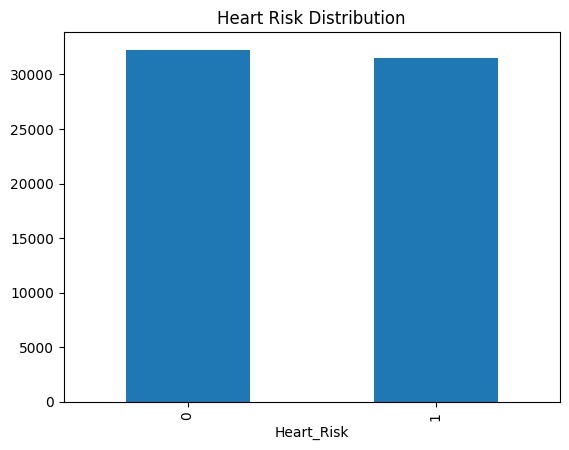

In [56]:
df["Heart_Risk"].value_counts().plot(kind="bar")
plt.title("Heart Risk Distribution")
plt.show()

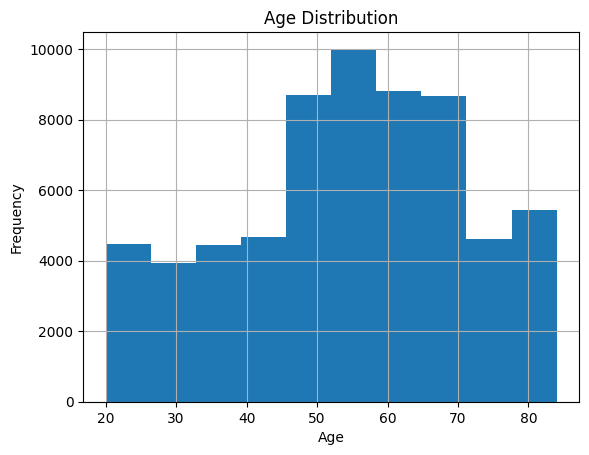

In [57]:
df["Age"].hist()
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

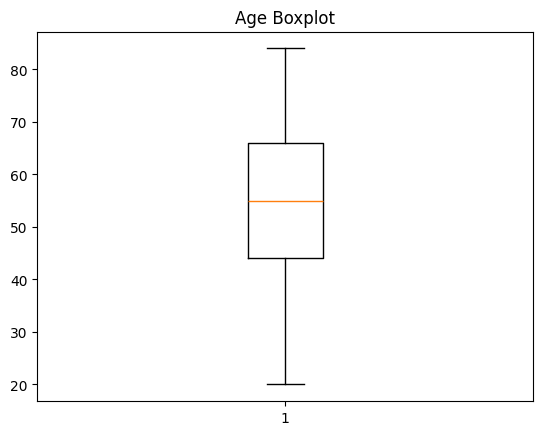

In [58]:
plt.boxplot(df["Age"])
plt.title("Age Boxplot")
plt.show()

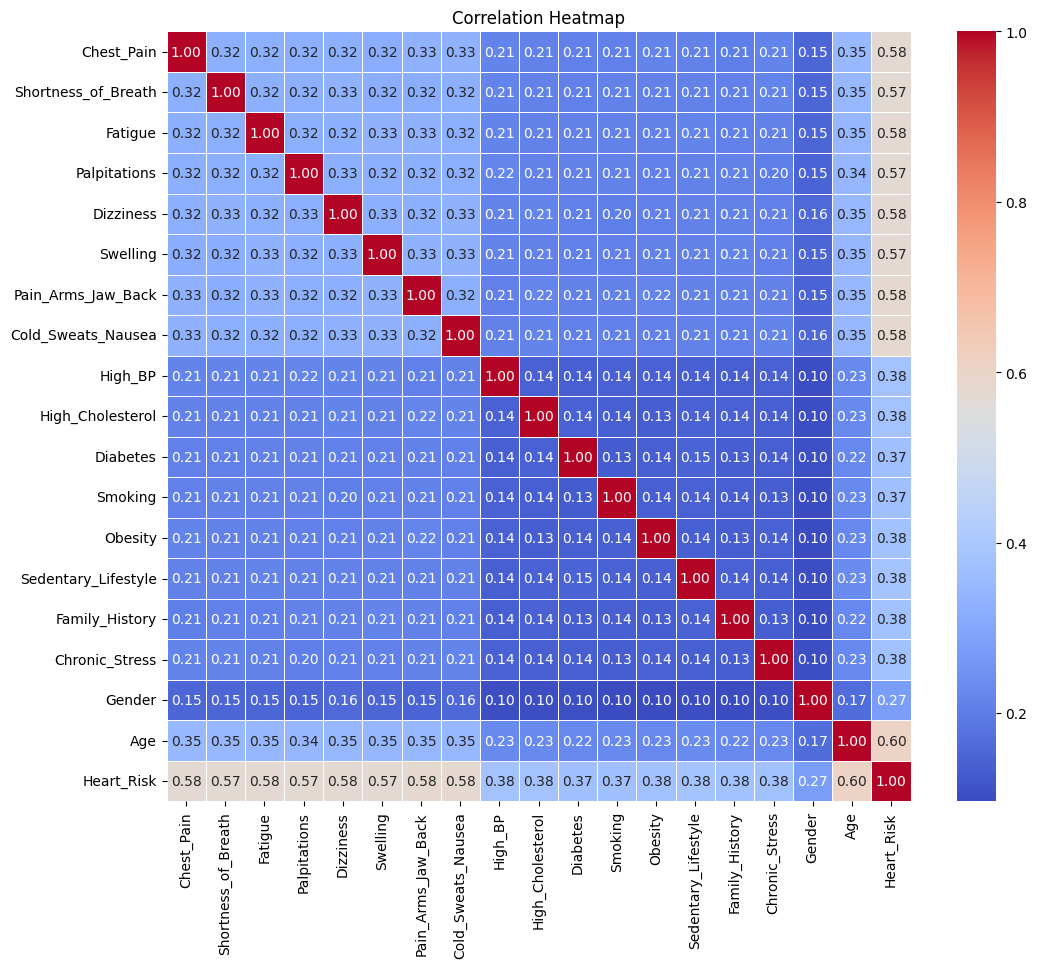

In [59]:
import seaborn as sns

corr = df.corr(numeric_only=True)

plt.figure(figsize=(12,10))

sns.heatmap(
    corr,
    annot=True,      # يكتب قيمة الارتباط داخل كل مربع
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()

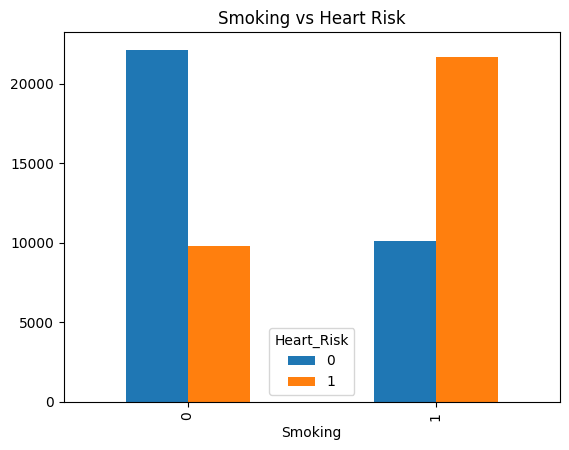

In [60]:
pd.crosstab(df["Smoking"], df["Heart_Risk"]).plot(kind="bar")

plt.title("Smoking vs Heart Risk")
plt.show()

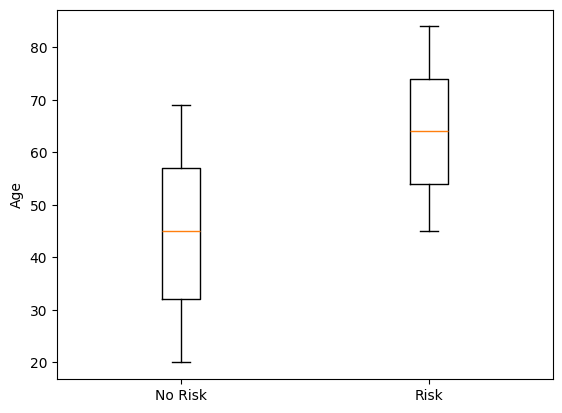

In [61]:
plt.boxplot([
    df[df["Heart_Risk"] == 0]["Age"],
    df[df["Heart_Risk"] == 1]["Age"]
])

plt.xticks([1, 2], ["No Risk", "Risk"])
plt.ylabel("Age")
plt.show()

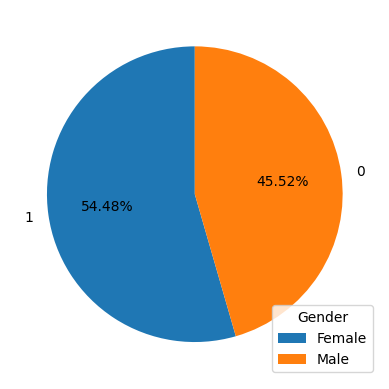

In [62]:
counts= df["Gender"].value_counts()
plt.pie(counts,labels=counts.index,autopct="%1.2f%%",startangle=90)
plt.legend(title="Gender", labels=["Female","Male"])

plt.show()

# **Featuer Engneer**

---



Add new columns with the help of current columns
here am adding symptom count for each row and risk factor

In [63]:
symptom_cols = [
    "Chest_Pain", "Shortness_of_Breath", "Fatigue", "Palpitations",
    "Dizziness", "Swelling", "Pain_Arms_Jaw_Back", "Cold_Sweats_Nausea"
]

df["Symptom_Count"] = df[symptom_cols].sum(axis=1)

risk_factor_cols = [
    "High_BP", "High_Cholesterol", "Diabetes", "Smoking",
    "Obesity", "Sedentary_Lifestyle", "Family_History", "Chronic_Stress"
]

df["Risk_Factor_Count"] = df[risk_factor_cols].sum(axis=1)

df["Age_Group"] = pd.cut(
    df["Age"],
    bins=[0, 40, 60, 100],
    labels=["Young", "Middle", "Senior"]
)

encode the group age

In [64]:
df["Age_Group"] = df["Age_Group"].map({
    "Young": 0,
    "Middle": 1,
    "Senior": 2
})

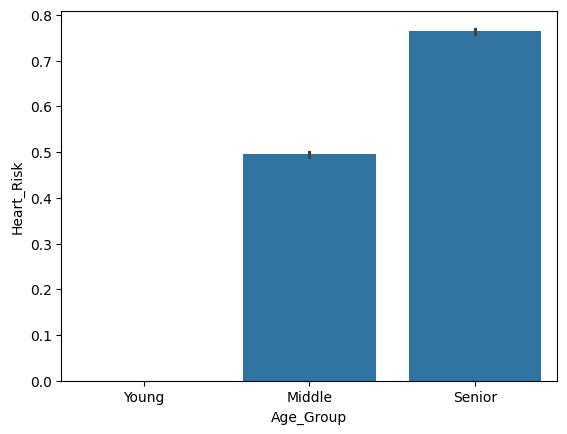

In [65]:

sns.barplot(data=df, x= "Age_Group",y='Heart_Risk')
plt.xticks(
    ticks=[0,1,2],
    labels=["Young","Middle","Senior"]
)
plt.show()

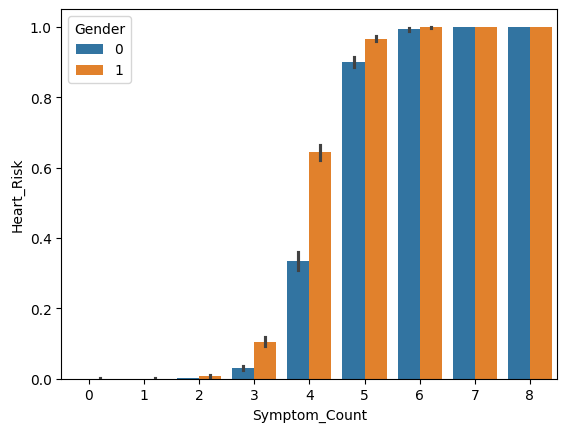

In [66]:
sns.barplot(data=df, x= "Symptom_Count",y='Heart_Risk',hue="Gender")

plt.show()

# **Model training**

---



Remove the target from the train data to avoid any data leakage

In [67]:
target = "Heart_Risk"
y= df[target]
X= df.drop(columns=[target])
print(X.shape , y.shape)

(63755, 21) (63755,)


check if there any string data type

In [68]:
X.select_dtypes(include="object").columns

Index([], dtype='object')

Split the data into a training and test dataset and determine the size of the test data (here 20% of the data is test data rest is training)

stratify guarantee same percent for each category

In [69]:
from sklearn.model_selection import train_test_split
X_train , X_test , y_train , y_test = train_test_split(
    X,y ,
    test_size=0.2,
    random_state = 42,
    stratify=y

)
print(X_train.shape, X_test.shape)

(51004, 21) (12751, 21)


# **Scaling**
---


In [70]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
# Fit the scaler on the training data and transform it
X_train_scaled = scaler.fit_transform(X_train)

# Transform the test data using the same scaling parameters
X_test_scaled = scaler.transform(X_test)

In [71]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled,y_train)
log_pred = log_model.predict(X_test_scaled)
print("Accuracy:",accuracy_score(y_test,log_pred))
print(classification_report(y_test,log_pred))

Accuracy: 0.9911379499647086
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      6454
           1       0.99      0.99      0.99      6297

    accuracy                           0.99     12751
   macro avg       0.99      0.99      0.99     12751
weighted avg       0.99      0.99      0.99     12751



In [72]:
print(X_train.columns)

Index(['Chest_Pain', 'Shortness_of_Breath', 'Fatigue', 'Palpitations',
       'Dizziness', 'Swelling', 'Pain_Arms_Jaw_Back', 'Cold_Sweats_Nausea',
       'High_BP', 'High_Cholesterol', 'Diabetes', 'Smoking', 'Obesity',
       'Sedentary_Lifestyle', 'Family_History', 'Chronic_Stress', 'Gender',
       'Age', 'Symptom_Count', 'Risk_Factor_Count', 'Age_Group'],
      dtype='object')


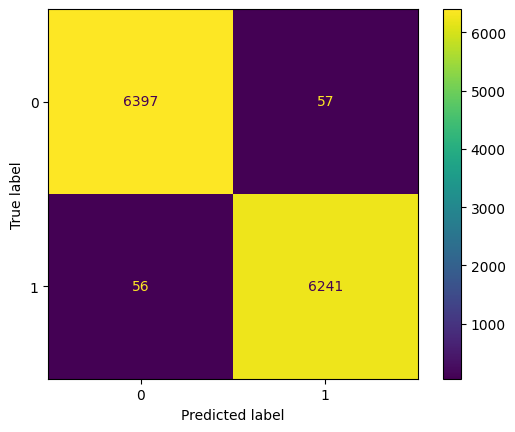

In [73]:

ConfusionMatrixDisplay.from_predictions(y_test, log_pred)
plt.show()

Decision Tree

---



In [74]:
tree_model = DecisionTreeClassifier(random_state=42)
tree_model.fit(X_train,y_train)
pred=tree_model.predict(X_test)
print("acc: ",accuracy_score(y_test,pred))
print(classification_report(y_test,pred))

acc:  0.9873735393302486
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      6454
           1       0.99      0.99      0.99      6297

    accuracy                           0.99     12751
   macro avg       0.99      0.99      0.99     12751
weighted avg       0.99      0.99      0.99     12751



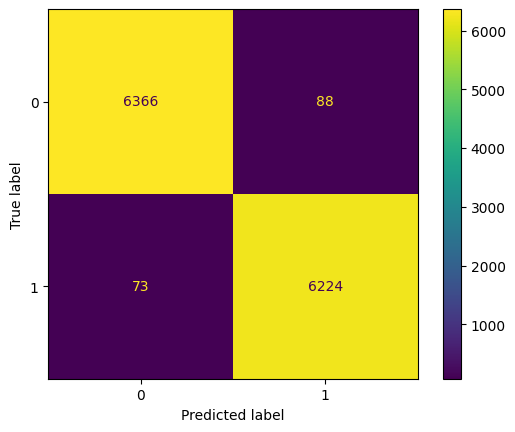

In [75]:
ConfusionMatrixDisplay.from_predictions(y_test,pred)
plt.show()

In [76]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

Accuracy: 0.9929417300603874
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      6454
           1       0.99      0.99      0.99      6297

    accuracy                           0.99     12751
   macro avg       0.99      0.99      0.99     12751
weighted avg       0.99      0.99      0.99     12751



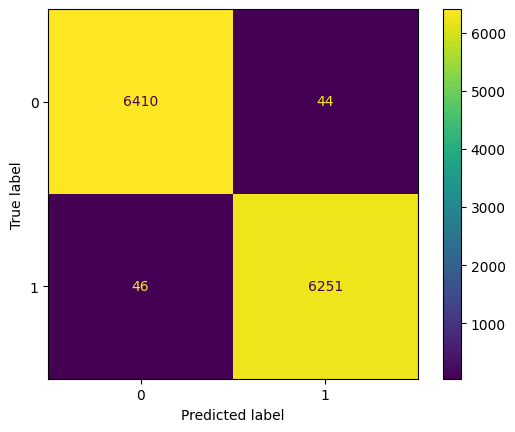

In [77]:
ConfusionMatrixDisplay.from_predictions(y_test, rf_pred)
plt.show()

# **PCA**

---



In [78]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)
print("Explained Variance Ratio:", pca.explained_variance_ratio_)
print("Total Explained Variance:", pca.explained_variance_ratio_.sum())

Explained Variance Ratio: [0.32603434 0.05988011]
Total Explained Variance: 0.3859144481757845


In [79]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train_pca, y_train)
rf_pred = rf_model.predict(X_test_pca)
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

Accuracy: 0.9907458238569524
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      6454
           1       0.99      0.99      0.99      6297

    accuracy                           0.99     12751
   macro avg       0.99      0.99      0.99     12751
weighted avg       0.99      0.99      0.99     12751

